#1. Prepare Data

In [1]:
!pip install resampy librosa==0.10.1 matplotlib seaborn scikit-learn tensorflow pandas

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import zipfile
import urllib.request
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import AdamW

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.7/253.7 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 113.8 MB/s eta 0:00:00
  Attempting uninstall: librosa
    Found existing installation: librosa 0.11.0
    Uninstalling librosa-0.11.0:
      Successfully uninstalled librosa-0.11.0


In [2]:

import zipfile
import os

url = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip?download=1"
filename = "ravdess_data.zip"
extract_path = "./ravdess_data"

if not os.path.exists(extract_path):
    print("[*] Downloading RAVDESS dataset...")
    urllib.request.urlretrieve(url, filename)
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
else:
    print("[!] Folder existed.")

print("[V] RAVDESS Dataset ok!")

# should download from Kaggle
filename = "CREMA-D.zip"
extract_path_crema = "./crema_data"

if not os.path.exists(extract_path_crema):
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(extract_path_crema)
else:
    print("[!] Folder existed.")

print("[V] CREMA-D Dataset ok!")

[*] Downloading RAVDESS dataset...
[V] RAVDESS Dataset ok!
[V] CREMA-D Dataset ok!


# 2. Preprocessing & Feature Extraction

In [7]:
import numpy as np
import librosa, os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

def noise(data):
    noise_factor = np.random.uniform(0.01, 0.05)
    noise_amp = noise_factor * np.amax(data)
    data = data + noise_amp * np.random.normal(size=data.shape[0])
    return data

def pitch(data, sampling_rate):
    steps = np.random.uniform(-2.5, 2.5)
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=steps)

def extract_features(data, sample_rate):
    target_len = 22050 * 2.5  # 2.5 sec
    if len(data) < target_len:
        data = np.pad(data, (0, int(target_len - len(data))), 'constant')
    else:
        data = data[:int(target_len)]

    # MFCC 提取
    mfccs = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=20, n_fft=2048, hop_length=512)
    mfccs = mfccs.T # (Time, Features)

    # 長度統一為 108 frames
    fixed_frames = 108
    if mfccs.shape[0] < fixed_frames:
        mfccs = np.pad(mfccs, ((0, fixed_frames - mfccs.shape[0]), (0,0)), 'constant')
    else:
        mfccs = mfccs[:fixed_frames, :]
    return mfccs

all_paths = []
all_labels = []

emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".wav"):
            part = file.split('-')
            emotion_code = part[2]
            if emotion_code in emotion_map:
                all_paths.append(os.path.join(root, file))
                all_labels.append(emotion_map[emotion_code])


all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

train_paths, test_paths, train_labels_raw, test_labels_raw = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)


def process_data(paths, labels, augment=False):
    X_list = []
    y_list = []

    for path, label in zip(paths, labels):
        data, sr = librosa.load(path, duration=2.5, offset=0.5, sr=22050)

        res_orig = extract_features(data, sr)
        X_list.append(res_orig)
        y_list.append(label)

        # 如果是訓練集，則額外加入增強樣本
        if augment:
            res_noise = extract_features(noise(data), sr)
            X_list.append(res_noise)
            y_list.append(label)

            res_pitch = extract_features(pitch(data, sr), sr)
            X_list.append(res_pitch)
            y_list.append(label)

    return np.array(X_list), np.array(y_list)

print("正在處理訓練集 (包含資料增強)...")
X_train, y_train_raw = process_data(train_paths, train_labels_raw, augment=True)

print("正在處理測試集 (無增強)...")
X_test, y_test_raw = process_data(test_paths, test_labels_raw, augment=False)

# One-Hot Encoding

encoder = OneHotEncoder()
encoder.fit(all_labels.reshape(-1, 1))

y_train = encoder.transform(y_train_raw.reshape(-1, 1)).toarray()
y_test = encoder.transform(y_test_raw.reshape(-1, 1)).toarray()

print(f"訓練集大小: {X_train.shape}, 標籤大小: {y_train.shape}")
print(f"測試集大小: {X_test.shape}, 標籤大小: {y_test.shape}")
print("[V] RAVDESS Preprocessing and Feature Extraction Completed!")

CREMA-D 訓練完成！訓練集：(17859, 108, 20), 測試集：(1489, 108, 20)


In [12]:
import numpy as np
import librosa, os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

def noise(data):
    noise_factor = np.random.uniform(0.01, 0.05)
    noise_amp = noise_factor * np.amax(data)
    data = data + noise_amp * np.random.normal(size=data.shape[0])
    return data

def pitch(data, sampling_rate):
    steps = np.random.uniform(-2.5, 2.5)
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=steps)

def extract_features_crema(data, sample_rate):
    target_len = 22050 * 2.5  # 2.5 sec
    if len(data) < target_len:
        data = np.pad(data, (0, int(target_len - len(data))), 'constant')
    else:
        data = data[:int(target_len)]

    mfccs = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=20, n_fft=2048, hop_length=512)
    mfccs = mfccs.T

    fixed_frames = 108
    if mfccs.shape[0] < fixed_frames:
        mfccs = np.pad(mfccs, ((0, fixed_frames - mfccs.shape[0]), (0,0)), 'constant')
    else:
        mfccs = mfccs[:fixed_frames, :]
    return mfccs

crema_paths = []
crema_labels = []

crema_map = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fearful',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad'
}

for root, dirs, files in os.walk(extract_path_crema):
    for file in files:
        if file.endswith(".wav"):
            part = file.split('_')
            if len(part) >= 3:
                emotion_code = part[2]
                if emotion_code in crema_map:
                    crema_paths.append(os.path.join(root, file))
                    crema_labels.append(crema_map[emotion_code])

crema_paths = np.array(crema_paths)
crema_labels = np.array(crema_labels)


X_train_paths, X_test_paths, y_train_labels, y_test_labels = train_test_split(
    crema_paths, crema_labels, test_size=0.2, random_state=42, stratify=crema_labels
)


def process_crema_dataset(paths, labels, augment=False):
    X_data = []
    y_data = []

    for path, label in zip(paths, labels):
        try:
            data, sr = librosa.load(path, duration=2.5, offset=0.5, sr=22050)

            X_data.append(extract_features_crema(data, sr))
            y_data.append(label)

            if augment:
                # Noise
                X_data.append(extract_features_crema(noise(data), sr))
                y_data.append(label)

                # Pitch
                X_data.append(extract_features_crema(pitch(data, sr), sr))
                y_data.append(label)

        except Exception as e:
            print(f"Error processing {path}: {e}")
            continue

    return np.array(X_data), np.array(y_data)

print("處理 CREMA-D 訓練集 (Augmentation ON)...")
X_train, y_train_raw = process_crema_dataset(X_train_paths, y_train_labels, augment=True)

print("處理 CREMA-D 測試集 (Augmentation OFF)...")
X_test, y_test_raw = process_crema_dataset(X_test_paths, y_test_labels, augment=False)

# One-Hot Encoding
encoder = OneHotEncoder()
encoder.fit(crema_labels.reshape(-1, 1))

y_train = encoder.transform(y_train_raw.reshape(-1, 1)).toarray()
y_test = encoder.transform(y_test_raw.reshape(-1, 1)).toarray()

print(f"CREMA-D 訓練完成！訓練集：{X_train.shape}, 測試集：{X_test.shape}")

處理 CREMA-D 訓練集 (Augmentation ON)...
處理 CREMA-D 測試集 (Augmentation OFF)...
CREMA-D 訓練完成！訓練集：(17859, 108, 20), 測試集：(1489, 108, 20)


#4. 1D CNN

In [15]:
from tensorflow.keras.layers import Dropout

def build_model(input_shape, num_classes):
    model = Sequential()

    # Block 1
    # 512 Filters, Kernel 5
    model.add(Conv1D(512, kernel_size=5, strides=1, padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling1D(pool_size=5, strides=2, padding='same'))
    model.add(Dropout(0.2))

    # Block 2
    # 512 Filters, Kernel 5
    model.add(Conv1D(512, kernel_size=5, strides=1, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling1D(pool_size=5, strides=2, padding='same'))
    model.add(Dropout(0.2))

    # Block 3
    # 256 Filters, Kernel 5
    model.add(Conv1D(256, kernel_size=5, strides=1, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling1D(pool_size=5, strides=2, padding='same'))
    model.add(Dropout(0.2))

    # Block 4
    # 256 Filters, Kernel 3
    model.add(Conv1D(256, kernel_size=3, strides=1, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling1D(pool_size=5, strides=2, padding='same'))
    model.add(Dropout(0.2))

    # Block 5
    # 128 Filters, Kernel 3
    model.add(Conv1D(128, kernel_size=3, strides=1, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling1D(pool_size=5, strides=2, padding='same'))
    model.add(Dropout(0.2))

    # Fully Connected Layer
    model.add(Flatten())
    model.add(Dense(512))
    model.add(Dropout(0.3))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Output Layer
    model.add(Dense(num_classes, activation='softmax'))

    return model

# create model
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]
model = build_model(input_shape, num_classes)
optimizer = AdamW(learning_rate=0.0001, weight_decay=5e-4)
model.compile(loss='categorical_crossentropy',  optimizer=optimizer, metrics=['accuracy'])
model.summary()
print("[*] Start training (Epochs=50)...")
history = model.fit(X_train, y_train, batch_size=64, epochs=50, validation_data=(X_test, y_test), verbose=1)

print("[V] Training Completed!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'tf' is not defined

# 5. Evaluation

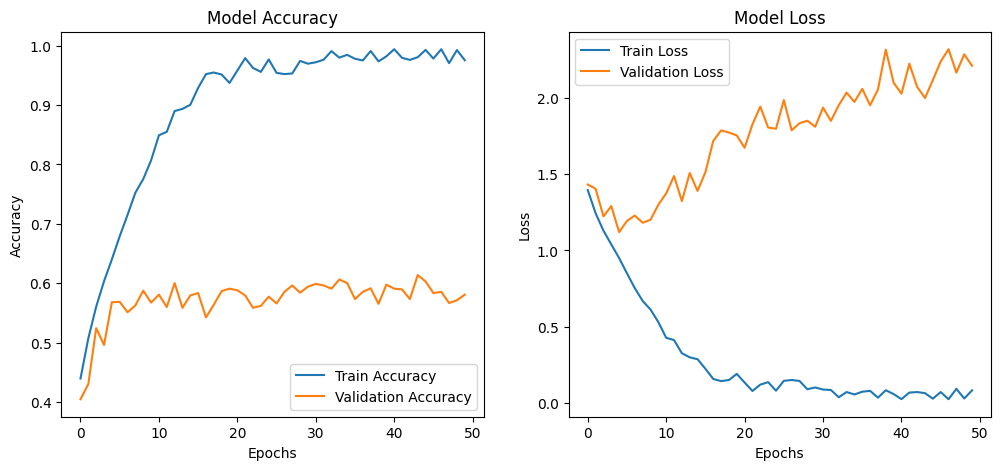


最終測試集準確率：58.09%
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


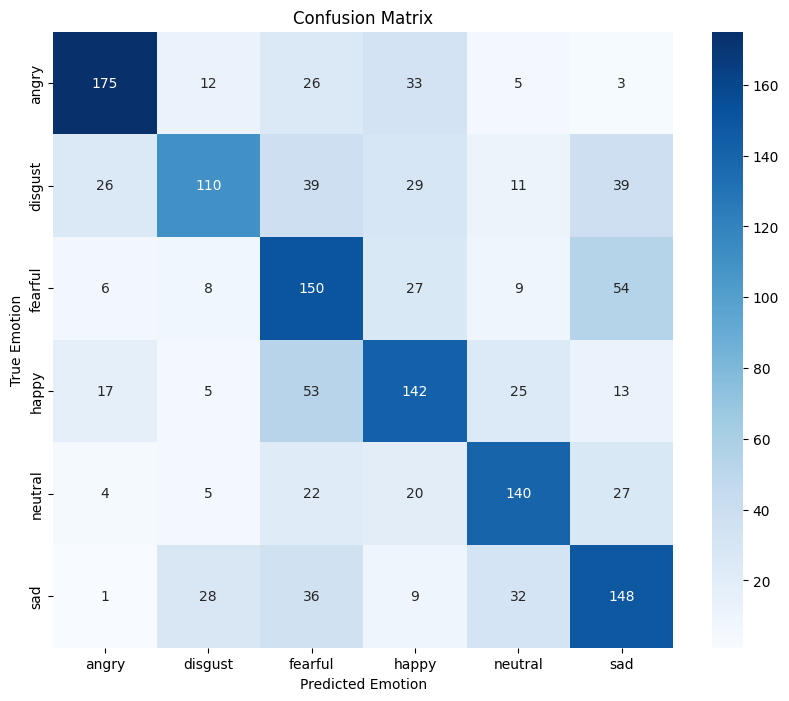


詳細分類報告：
              precision    recall  f1-score   support

       angry       0.76      0.69      0.72       254
     disgust       0.65      0.43      0.52       254
     fearful       0.46      0.59      0.52       254
       happy       0.55      0.56      0.55       255
     neutral       0.63      0.64      0.64       218
         sad       0.52      0.58      0.55       254

    accuracy                           0.58      1489
   macro avg       0.60      0.58      0.58      1489
weighted avg       0.60      0.58      0.58      1489



In [14]:
# Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Test Accuracy
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n最終測試集準確率：{acc*100:.2f}%")

# Confusion Matrix
pred_y = model.predict(X_test)
pred_classes = np.argmax(pred_y, axis=1)
true_classes = np.argmax(y_test, axis=1)

labels = encoder.categories_[0]

cm = confusion_matrix(true_classes, pred_classes)

# draw
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

print("\n詳細分類報告：")
print(classification_report(true_classes, pred_classes, target_names=labels))